Web Scraping and Analysis of US Failed Banks 

In [1]:
import pandas as pd
import numpy as np


In [3]:
!pip install lxml
!pip install html5lib
!pip install beautifulsoup4

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:

url="https://www.fdic.gov/bank-failures/failed-bank-list/"

df=pd.read_html(url)

In [5]:
df[0]

,Bank Name,City,State,Cert,Acquiring Institution,Closing Date,Fund Sort ascending
0,Community Bank and Trust - West Georgia,LaGrange,Georgia,25796,Anchor Bank,"May 1, 2026",10551
1,Metropolitan Capital Bank & Trust,Chicago,Illinois,57488,First Independence Bank,"January 30, 2026",10550
2,The Santa Anna National Bank,Santa Anna,Texas,5520,Coleman County State Bank,"June 27, 2025",10549
3,Pulaski Savings Bank,Chicago,Illinois,28611,Millennium Bank,"January 17, 2025",10548
4,The First National Bank of Lindsay,Lindsay,Oklahoma,4134,First Bank & Trust Co.,"October 18, 2024",10547
5,Republic First Bank dba Republic Bank,Philadelphia,Pennsylvania,27332,"Fulton Bank, National Association","April 26, 2024",10546
6,Citizens Bank,Sac City,Iowa,8758,Iowa Trust & Savings Bank,"November 3, 2023",10545
7,Heartland Tri-State Bank,Elkhart,Kansas,25851,"Dream First Bank, N.A.","July 28, 2023",10544
8,First Republic Bank,San Francisco,California,59017,"JPMorgan Chase Bank, N.A.","May 1, 2023",10543
9,Signature Bank,New York,New York,57053,"Flagstar Bank, N.A.","March 12, 2023",10540


In [6]:
all_data = []

for page in range(1, 24):   # 1 to 23
    url = f"https://www.fdic.gov/bank-failures/failed-bank-list?pg={page}"
    
    print("Scraping page:", page)

    df_page = pd.read_html(url)
    all_data.append(df_page[0])  # Append the first table from each page

# সব page merge করে একটা DataFrame
final_df = pd.concat(all_data, ignore_index=True)

print("Total records:", len(final_df))
final_df.head()

Scraping page: 1
Scraping page: 2
Scraping page: 3
Scraping page: 4
Scraping page: 5
Scraping page: 6
Scraping page: 7
Scraping page: 8
Scraping page: 9
Scraping page: 10
Scraping page: 11
Scraping page: 12
Scraping page: 13
Scraping page: 14
Scraping page: 15
Scraping page: 16
Scraping page: 17
Scraping page: 18
Scraping page: 19
Scraping page: 20
Scraping page: 21
Scraping page: 22
Scraping page: 23
Total records: 574


,Bank Name,City,State,Cert,Acquiring Institution,Closing Date,Fund Sort ascending
0,Community Bank and Trust - West Georgia,LaGrange,Georgia,25796,Anchor Bank,"May 1, 2026",10551
1,Metropolitan Capital Bank & Trust,Chicago,Illinois,57488,First Independence Bank,"January 30, 2026",10550
2,The Santa Anna National Bank,Santa Anna,Texas,5520,Coleman County State Bank,"June 27, 2025",10549
3,Pulaski Savings Bank,Chicago,Illinois,28611,Millennium Bank,"January 17, 2025",10548
4,The First National Bank of Lindsay,Lindsay,Oklahoma,4134,First Bank & Trust Co.,"October 18, 2024",10547


In [7]:
final_df


,Bank Name,City,State,Cert,Acquiring Institution,Closing Date,Fund Sort ascending
0,Community Bank and Trust - West Georgia,LaGrange,Georgia,25796,Anchor Bank,"May 1, 2026",10551
1,Metropolitan Capital Bank & Trust,Chicago,Illinois,57488,First Independence Bank,"January 30, 2026",10550
2,The Santa Anna National Bank,Santa Anna,Texas,5520,Coleman County State Bank,"June 27, 2025",10549
3,Pulaski Savings Bank,Chicago,Illinois,28611,Millennium Bank,"January 17, 2025",10548
4,The First National Bank of Lindsay,Lindsay,Oklahoma,4134,First Bank & Trust Co.,"October 18, 2024",10547
...,...,...,...,...,...,...,...
569,Sinclair National Bank,Gravette,Arkansas,34248,Delta Trust & Bank,"September 7, 2001",4649
570,Malta National Bank,Malta,Ohio,6629,North Valley Bank,"May 3, 2001",4648
571,First Alliance Bank & Trust Co.,Manchester,New Hampshire,34264,Southern New Hampshire Bank & Trust,"February 2, 2001",4647
572,The National State Bank of Metropolis,Metropolis,Illinois,3815,Banterra Bank of Marion,"December 14, 2000",4646


In [8]:
final_df.to_csv("failed_banks.csv", index=False)

In [9]:
final_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 574 entries, 0 to 573
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Bank Name              574 non-null    object
 1   City                   574 non-null    object
 2   State                  574 non-null    object
 3   Cert                   574 non-null    int64 
 4   Acquiring Institution  574 non-null    object
 5   Closing Date           574 non-null    object
 6   Fund  Sort ascending   574 non-null    int64 
dtypes: int64(2), object(5)
memory usage: 31.5+ KB


In [10]:
final_df.head(10)

,Bank Name,City,State,Cert,Acquiring Institution,Closing Date,Fund Sort ascending
0,Community Bank and Trust - West Georgia,LaGrange,Georgia,25796,Anchor Bank,"May 1, 2026",10551
1,Metropolitan Capital Bank & Trust,Chicago,Illinois,57488,First Independence Bank,"January 30, 2026",10550
2,The Santa Anna National Bank,Santa Anna,Texas,5520,Coleman County State Bank,"June 27, 2025",10549
3,Pulaski Savings Bank,Chicago,Illinois,28611,Millennium Bank,"January 17, 2025",10548
4,The First National Bank of Lindsay,Lindsay,Oklahoma,4134,First Bank & Trust Co.,"October 18, 2024",10547
5,Republic First Bank dba Republic Bank,Philadelphia,Pennsylvania,27332,"Fulton Bank, National Association","April 26, 2024",10546
6,Citizens Bank,Sac City,Iowa,8758,Iowa Trust & Savings Bank,"November 3, 2023",10545
7,Heartland Tri-State Bank,Elkhart,Kansas,25851,"Dream First Bank, N.A.","July 28, 2023",10544
8,First Republic Bank,San Francisco,California,59017,"JPMorgan Chase Bank, N.A.","May 1, 2023",10543
9,Signature Bank,New York,New York,57053,"Flagstar Bank, N.A.","March 12, 2023",10540


In [11]:
final_df.tail(10)

,Bank Name,City,State,Cert,Acquiring Institution,Closing Date,Fund Sort ascending
564,Net First National Bank,Boca Raton,Florida,26652,Bank Leumi USA,"March 1, 2002",4654
565,"NextBank, NA",Phoenix,Arizona,22314,No Acquirer,"February 7, 2002",4653
566,Oakwood Deposit Bank Co.,Oakwood,Ohio,8966,The State Bank & Trust Company,"February 1, 2002",4652
567,Bank of Sierra Blanca,Sierra Blanca,Texas,22002,The Security State Bank of Pecos,"January 18, 2002",4651
568,"Hamilton Bank, N.A.",Miami,Florida,24382,Israel Discount Bank of New York,"January 11, 2002",4650
569,Sinclair National Bank,Gravette,Arkansas,34248,Delta Trust & Bank,"September 7, 2001",4649
570,Malta National Bank,Malta,Ohio,6629,North Valley Bank,"May 3, 2001",4648
571,First Alliance Bank & Trust Co.,Manchester,New Hampshire,34264,Southern New Hampshire Bank & Trust,"February 2, 2001",4647
572,The National State Bank of Metropolis,Metropolis,Illinois,3815,Banterra Bank of Marion,"December 14, 2000",4646
573,Bank of Honolulu,Honolulu,Hawaii,21029,Bank of the Orient,"October 13, 2000",4645


In [12]:
final_df.describe()

,Cert,Fund Sort ascending
count,574.000000,574.000000
mean,31589.090592,10046.625436
std,16506.865340,1106.784855
min,91.000000,4645.000000
25%,20087.250000,10119.250000
50%,32016.500000,10262.500000
75%,35368.000000,10405.750000
max,59017.000000,10551.000000


In [16]:
final_df["Bank Name"].value_counts()

Bank Name
The First State Bank                     3
First State Bank                         3
Premier Bank                             3
Horizon Bank                             3
The Park Avenue Bank                     2
                                        ..
Sinclair National Bank                   1
Malta National Bank                      1
First Alliance Bank & Trust Co.          1
The National State Bank of Metropolis    1
Almena State Bank                        1
Name: count, Length: 555, dtype: int64

In [25]:
final_df[final_df.duplicated()]

,Bank Name,City,State,Cert,Acquiring Institution,Closing Date,Fund Sort ascending


In [26]:
final_df.isnull().sum()

Bank Name                0
City                     0
State                    0
Cert                     0
Acquiring Institution    0
Closing Date             0
Fund  Sort ascending     0
dtype: int64

In [35]:
final_df["City"].unique()

array(['LaGrange', 'Chicago', 'Santa Anna', 'Lindsay', 'Philadelphia',
       'Sac City', 'Elkhart', 'San Francisco', 'New York', 'Santa Clara',
       'Almena', 'Fort Walton Beach', 'Barboursville', 'Ericson',
       'Newark', 'Maumee', 'Louisa', 'Cooper', 'Argonia', 'Saint Elmo',
       'Milwaukee', 'New Orleans', 'Cottonwood Heights', 'Pennsville',
       'Mulberry', 'Woodbury', 'King of Prussia', 'Memphis', 'Longview',
       'Peachtree City', 'Denver', 'San Juan', 'Atlanta', 'Crestview',
       'Mankato', 'Palm Desert', 'Rising Sun', 'Conyers', 'Freedom',
       'Moline', 'Fort Lauderdale', 'Bel Air', 'Cincinnati', 'Berwyn',
       'Fairfax', 'Horsham', 'Sterling', 'Boise', 'El Reno',
       'West Chicago', 'The Woodlands', 'Graceville', 'Bridgeport',
       'Edinburg', 'Phoenix', 'Parsons', 'Wausau', 'Fort Myers',
       'Sevierville', 'North Las Vegas', 'Valdosta', 'Asheville',
       'Scottsdale', 'Kenosha', 'Lenoir', 'Douglasville', 'Orange Park',
       'Lexington', 'Marianna

In [36]:
final_df["State"].unique()

array(['Georgia', 'Illinois', 'Texas', 'Oklahoma', 'Pennsylvania', 'Iowa',
       'Kansas', 'California', 'New York', 'Florida', 'West Virginia',
       'Nebraska', 'New Jersey', 'Ohio', 'Kentucky', 'Wisconsin',
       'Louisiana', 'Utah', 'Arkansas', 'Tennessee', 'Washington',
       'Colorado', 'Puerto Rico', 'Minnesota', 'Maryland',
       'South Carolina', 'Virginia', 'Idaho', 'Connecticut', 'Arizona',
       'Nevada', 'North Carolina', 'Missouri', 'Alabama', 'Michigan',
       'Indiana', 'Mississippi', 'New Mexico', 'Oregon', 'Massachusetts',
       'South Dakota', 'Wyoming', 'New Hampshire', 'Hawaii'], dtype=object)

In [ ]:
final_df["Closing Date"]=pd.to_datetime(final_df["Closing Date"])
final_df["Closing Date"].dtype


Timestamp('2026-05-01 00:00:00')

In [38]:
final_df["Closing Date"].max()

Timestamp('2026-05-01 00:00:00')

In [41]:
final_df["Closing Date"].min()

Timestamp('2000-10-13 00:00:00')

In [43]:
final_df.head()

,Bank Name,City,State,Cert,Acquiring Institution,Closing Date,Fund Sort ascending
0,Community Bank and Trust - West Georgia,LaGrange,Georgia,25796,Anchor Bank,2026-05-01,10551
1,Metropolitan Capital Bank & Trust,Chicago,Illinois,57488,First Independence Bank,2026-01-30,10550
2,The Santa Anna National Bank,Santa Anna,Texas,5520,Coleman County State Bank,2025-06-27,10549
3,Pulaski Savings Bank,Chicago,Illinois,28611,Millennium Bank,2025-01-17,10548
4,The First National Bank of Lindsay,Lindsay,Oklahoma,4134,First Bank & Trust Co.,2024-10-18,10547


In [44]:
df = final_df.sort_values(by="Closing Date", ascending=True)

In [45]:
df.head()

,Bank Name,City,State,Cert,Acquiring Institution,Closing Date,Fund Sort ascending
573,Bank of Honolulu,Honolulu,Hawaii,21029,Bank of the Orient,2000-10-13,4645
572,The National State Bank of Metropolis,Metropolis,Illinois,3815,Banterra Bank of Marion,2000-12-14,4646
571,First Alliance Bank & Trust Co.,Manchester,New Hampshire,34264,Southern New Hampshire Bank & Trust,2001-02-02,4647
570,Malta National Bank,Malta,Ohio,6629,North Valley Bank,2001-05-03,4648
552,"Superior Bank, FSB",Hinsdale,Illinois,32646,"Superior Federal, FSB",2001-07-27,6004


In [46]:
df = df.rename(columns={"Fund  Sort ascending": "Fund"})

In [47]:
df.head()

,Bank Name,City,State,Cert,Acquiring Institution,Closing Date,Fund
573,Bank of Honolulu,Honolulu,Hawaii,21029,Bank of the Orient,2000-10-13,4645
572,The National State Bank of Metropolis,Metropolis,Illinois,3815,Banterra Bank of Marion,2000-12-14,4646
571,First Alliance Bank & Trust Co.,Manchester,New Hampshire,34264,Southern New Hampshire Bank & Trust,2001-02-02,4647
570,Malta National Bank,Malta,Ohio,6629,North Valley Bank,2001-05-03,4648
552,"Superior Bank, FSB",Hinsdale,Illinois,32646,"Superior Federal, FSB",2001-07-27,6004


In [48]:
df.to_csv("final_failed_banks.csv", index=False)

In [49]:
state_counts = df["State"].value_counts()

print(state_counts.head(10))

State
Georgia       94
Florida       76
Illinois      71
California    43
Minnesota     23
Washington    19
Missouri      16
Arizona       16
Michigan      14
Texas         14
Name: count, dtype: int64


Most failed bank state

In [50]:
top_state = df["State"].value_counts().idxmax()
print("Most failed bank state:", top_state)

Most failed bank state: Georgia


Most failed year

In [55]:
top_year = df["Closing Date"].value_counts().idxmax()
print("Most failed year:", top_year)

Most failed year: 2009-10-30 00:00:00


In [58]:
acquirer_counts = df["Acquiring Institution"].value_counts()

print(acquirer_counts.head(10))

Acquiring Institution
No Acquirer                            31
State Bank and Trust Company           12
First-Citizens Bank & Trust Company    11
Ameris Bank                            10
U.S. Bank N.A.                          9
Community & Southern Bank               8
Stearns Bank, N.A.                      7
Centennial Bank                         7
Bank of the Ozarks                      7
Central Bank                            6
Name: count, dtype: int64


Top acquiring institution

In [57]:
top_acquirer = df["Acquiring Institution"].value_counts().idxmax()
print("Top acquiring institution:", top_acquirer)

Top acquiring institution: No Acquirer


Total_fund_loss

In [60]:
total_fund_loss = df["Fund"].sum()

print("Total Fund Loss:", total_fund_loss)

Total Fund Loss: 5766763


Average Fund Loss

In [62]:
print("Average Fund Loss:", df["Fund"].mean())

Average Fund Loss: 10046.625435540069


Top 10 State fund loss

In [63]:
state_fund = df.groupby("State")["Fund"].sum().sort_values(ascending=False)

print(state_fund.head(10))

State
Georgia       959500
Florida       764744
Illinois      715881
California    432940
Minnesota     235976
Washington    194884
Missouri      164012
Arizona       158881
Texas         137946
Michigan      137544
Name: Fund, dtype: int64


In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

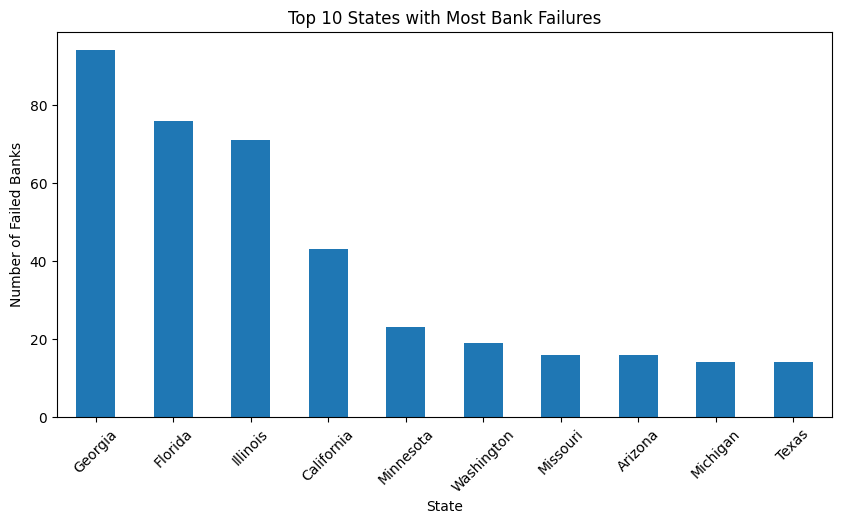

In [65]:
plt.figure(figsize=(10,5))

df["State"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 States with Most Bank Failures")
plt.xlabel("State")
plt.ylabel("Number of Failed Banks")
plt.xticks(rotation=45)
plt.show()

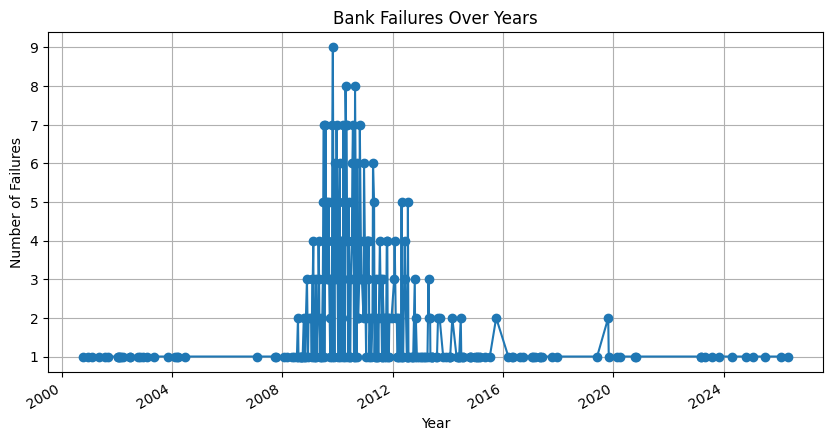

In [66]:
plt.figure(figsize=(10,5))

df["Closing Date"].value_counts().sort_index().plot(kind="line", marker="o")

plt.title("Bank Failures Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Failures")
plt.grid()
plt.show()

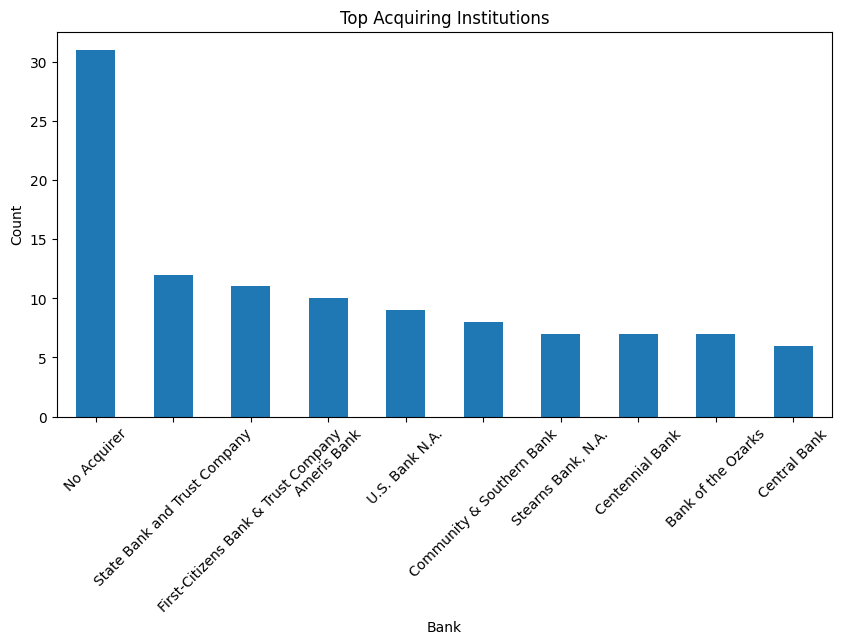

In [67]:
plt.figure(figsize=(10,5))

df["Acquiring Institution"].value_counts().head(10).plot(kind="bar")

plt.title("Top Acquiring Institutions")
plt.xlabel("Bank")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

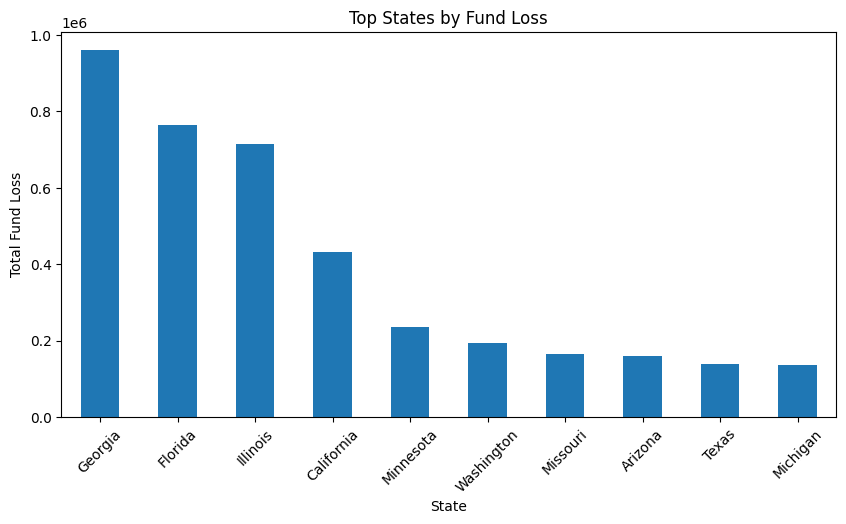

In [68]:
state_fund = df.groupby("State")["Fund"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
state_fund.head(10).plot(kind="bar")

plt.title("Top States by Fund Loss")
plt.xlabel("State")
plt.ylabel("Total Fund Loss")
plt.xticks(rotation=45)
plt.show()